### 📈 You Don't Need to Backtest Your Trading Strategies

##### ▶️ Related Quant Guild Videos:

- [The 5 Papers That Built Modern Quant Finance](https://youtu.be/ZwS1gMGegrM)

- [I Bet You've Never Found Alpha (and I Can Prove It)](https://youtu.be/UzTJHs3-eT0)

- [Quant Ranks Retail Trading Mistakes that Blow Up Your Account](https://youtu.be/1mpNxBaBeOw)

- [Non-Stationarity and Why Market Timing Fails](https://youtu.be/7nvjrgqKjJE)

- [Quant Busts 3 Trading Myths with Math](https://youtu.be/wJfIk3VnubE)

- [How to Read Options Chains](https://youtu.be/RrRbz6oXwxE)

###### ______________________________________________________________________________________________________________________________________

##### [🚀 Master your Quantitative Skills with Quant Guild](https://quantguild.com)

##### [📚 Visit the Quant Guild Library for more Jupyter Notebooks](https://github.com/romanmichaelpaolucci/Quant-Guild-Library)

##### [📈 Interactive Brokers for Algorithmic Trading](https://www.interactivebrokers.com/mkt/?src=quantguildY&url=%2Fen%2Fwhyib%2Foverview.php)

##### [👾 Join the Quant Guild Discord Server](discord.com/invite/MJ4FU2c6c3)

---

ERROR -1 2104 Market data farm connection is OK:cashfarm
ERROR -1 2104 Market data farm connection is OK:uscrypto
ERROR -1 2104 Market data farm connection is OK:usfuture
ERROR -1 2104 Market data farm connection is OK:usopt.nj
ERROR -1 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 2104 Market data farm connection is OK:usfarm
ERROR -1 2104 Market data farm connection is OK:usopt
ERROR -1 2106 HMDS data farm connection is OK:euhmds
ERROR -1 2106 HMDS data farm connection is OK:fundfarm
ERROR -1 2106 HMDS data farm connection is OK:ushmds
ERROR -1 2158 Sec-def data farm connection is OK:secdefil


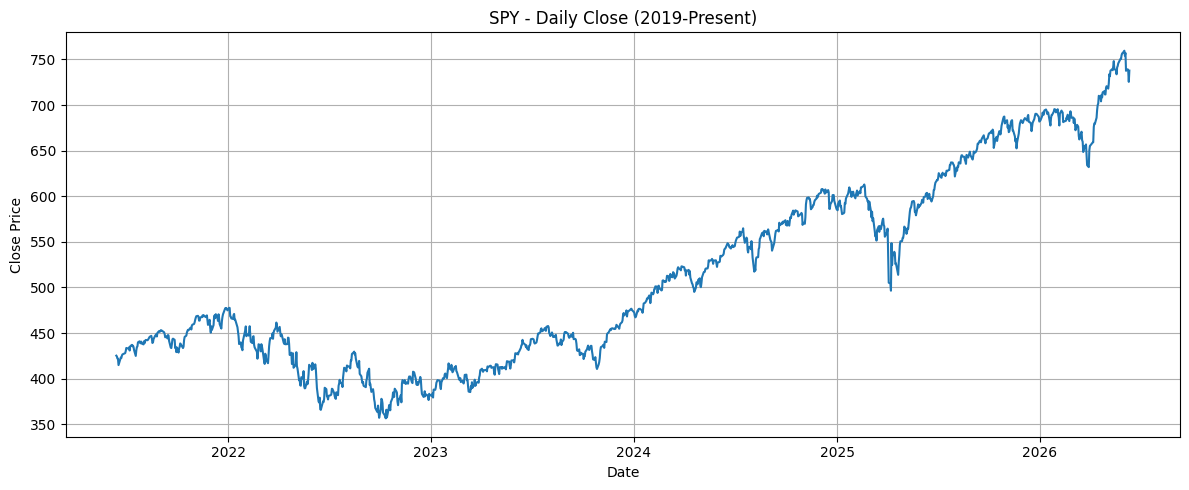

Sharpe Ratio (daily, annualized): 0.73
CAGR: 11.67%
Max Drawdown: -25.36%


In [29]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from threading import Thread

class IBData(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.data = []
        self.done = False

    def historicalData(self, reqId, bar):
        self.data.append([bar.date, bar.open, bar.high, bar.low, bar.close, bar.volume])

    def historicalDataEnd(self, reqId, start, end):
        self.done = True

def run_loop(app):
    app.run()

# Set up IB API Client
app = IBData()
app.connect("127.0.0.1", 7497, clientId=1)
api_thread = Thread(target=run_loop, args=(app,), daemon=True)
api_thread.start()

time.sleep(1)

# Define SPY contract
contract = Contract()
contract.symbol = "SPY"
contract.secType = "STK"
contract.exchange = "ARCA"
contract.currency = "USD"

# Request daily historical data from 2019-01-01 to now
end_date = ""
duration_str = "5 Y"    # Get up to 5 years of data
bar_size = "1 day"

app.reqHistoricalData(
    reqId=1,
    contract=contract,
    endDateTime=end_date,
    durationStr=duration_str,
    barSizeSetting=bar_size,
    whatToShow="TRADES",
    useRTH=1,
    formatDate=1,
    keepUpToDate=False,
    chartOptions=[]
)

timeout = 20   # seconds
t0 = time.time()
while not app.done and (time.time() - t0) < timeout:
    time.sleep(0.2)

app.disconnect()

# Convert data to DataFrame
df = pd.DataFrame(app.data, columns=["date", "open", "high", "low", "close", "volume"])
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df[df.index >= "2019-01-01"]
df['close'] = df['close'].astype(float)

# Visualization
plt.figure(figsize=(12,5))
plt.plot(df.index, df['close'])
plt.title('SPY - Daily Close (2019-Present)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sharpe Ratio and CAGR Calculation
returns = df['close'].pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

years = (df.index[-1] - df.index[0]).days / 365.25
cagr = ((df['close'].iloc[-1] / df['close'].iloc[0]) ** (1 / years)) - 1

# Max Drawdown Calculation
cum_returns = (1 + returns).cumprod()
cum_max = cum_returns.cummax()
drawdown = (cum_returns - cum_max) / cum_max
max_drawdown = drawdown.min()

print(f"Sharpe Ratio (daily, annualized): {sharpe:.2f}")
print(f"CAGR: {cagr:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")

In [33]:
# 2x leverage results
leverage = 1
leveraged_returns = returns * leverage
leveraged_sharpe = (leveraged_returns.mean() / leveraged_returns.std()) * np.sqrt(252)

leveraged_cum_returns = (1 + leveraged_returns).cumprod()
leveraged_cum_max = leveraged_cum_returns.cummax()
leveraged_drawdown = (leveraged_cum_returns - leveraged_cum_max) / leveraged_cum_max
leveraged_max_drawdown = leveraged_drawdown.min()

leveraged_cagr = ((df['close'].iloc[-1] / df['close'].iloc[0]) ** (leverage / years)) - 1

print(f"Sharpe Ratio 2x Leverage (daily, annualized): {leveraged_sharpe:.2f}")
print(f"CAGR 2x Leverage: {leveraged_cagr:.2%}")
print(f"Max Drawdown 2x Leverage: {leveraged_max_drawdown:.2%}")

Sharpe Ratio 2x Leverage (daily, annualized): 0.73
CAGR 2x Leverage: 11.67%
Max Drawdown 2x Leverage: -25.36%


ERROR -1 2104 Market data farm connection is OK:cashfarm
ERROR -1 2104 Market data farm connection is OK:uscrypto
ERROR -1 2104 Market data farm connection is OK:usfuture
ERROR -1 2104 Market data farm connection is OK:usopt.nj
ERROR -1 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 2104 Market data farm connection is OK:usfarm
ERROR -1 2104 Market data farm connection is OK:usopt
ERROR -1 2106 HMDS data farm connection is OK:euhmds
ERROR -1 2106 HMDS data farm connection is OK:fundfarm
ERROR -1 2106 HMDS data farm connection is OK:ushmds
ERROR -1 2158 Sec-def data farm connection is OK:secdefil


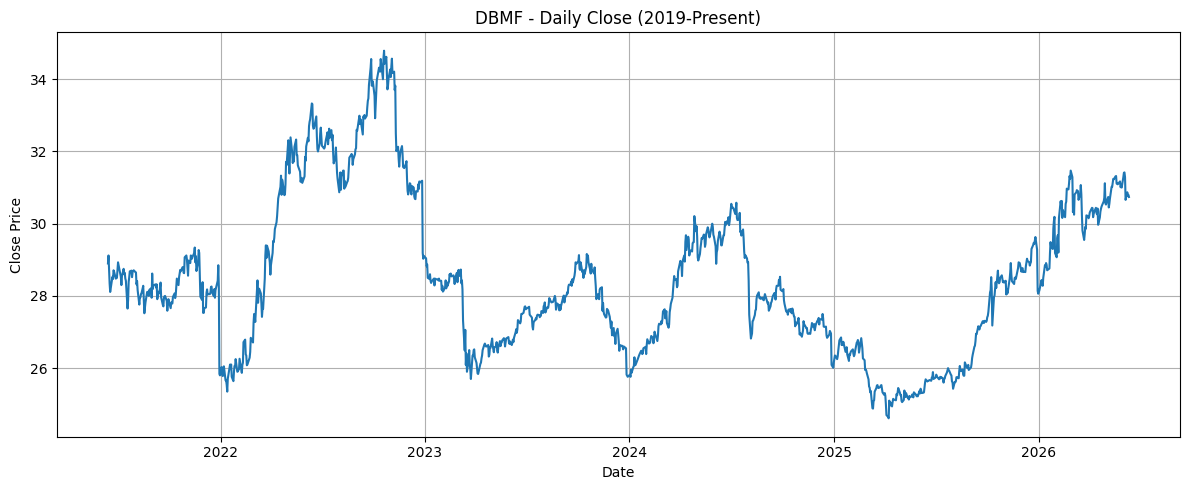

Sharpe Ratio (daily, annualized): 0.16
CAGR: 1.24%


In [11]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from threading import Thread

class IBData(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.data = []
        self.done = False

    def historicalData(self, reqId, bar):
        self.data.append([bar.date, bar.open, bar.high, bar.low, bar.close, bar.volume])

    def historicalDataEnd(self, reqId, start, end):
        self.done = True

def run_loop(app):
    app.run()

# Set up IB API Client
app = IBData()
app.connect("127.0.0.1", 7497, clientId=1)
api_thread = Thread(target=run_loop, args=(app,), daemon=True)
api_thread.start()

time.sleep(1)

# Define DBMF contract
contract = Contract()
contract.symbol = "DBMF"
contract.secType = "STK"
contract.exchange = "ARCA"
contract.currency = "USD"

# Request daily historical data from 2019-01-01 to now
end_date = ""
duration_str = "5 Y"    # Get up to 5 years of data
bar_size = "1 day"

app.reqHistoricalData(
    reqId=1,
    contract=contract,
    endDateTime=end_date,
    durationStr=duration_str,
    barSizeSetting=bar_size,
    whatToShow="TRADES",
    useRTH=1,
    formatDate=1,
    keepUpToDate=False,
    chartOptions=[]
)

timeout = 20   # seconds
t0 = time.time()
while not app.done and (time.time() - t0) < timeout:
    time.sleep(0.2)

app.disconnect()

# Convert data to DataFrame
df = pd.DataFrame(app.data, columns=["date", "open", "high", "low", "close", "volume"])
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df[df.index >= "2019-01-01"]
df['close'] = df['close'].astype(float)

# Visualization
plt.figure(figsize=(12,5))
plt.plot(df.index, df['close'])
plt.title('DBMF - Daily Close (2019-Present)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sharpe Ratio and CAGR Calculation
returns_DBMF = df['close'].pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

years = (df.index[-1] - df.index[0]).days / 365.25
cagr = ((df['close'].iloc[-1] / df['close'].iloc[0]) ** (1 / years)) - 1

print(f"Sharpe Ratio (daily, annualized): {sharpe:.2f}")
print(f"CAGR: {cagr:.2%}")

In [14]:
import statsmodels.api as sm

# Align the two return series and drop NA
returns_aligned = pd.concat([returns, returns_DBMF], axis=1, join='inner')
returns_aligned.columns = ["SPY", "DBMF"]

# CAPM regression: SPY (dependent) ~ DBMF (independent)
X = returns_aligned["DBMF"]
y = returns_aligned["SPY"]
X = sm.add_constant(X)
capm_model = sm.OLS(y, X).fit()
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SPY   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     8.951
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00283
Time:                        21:20:14   Log-Likelihood:                 3901.6
No. Observations:                1254   AIC:                            -7799.
Df Residuals:                    1252   BIC:                            -7789.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.604      0.1

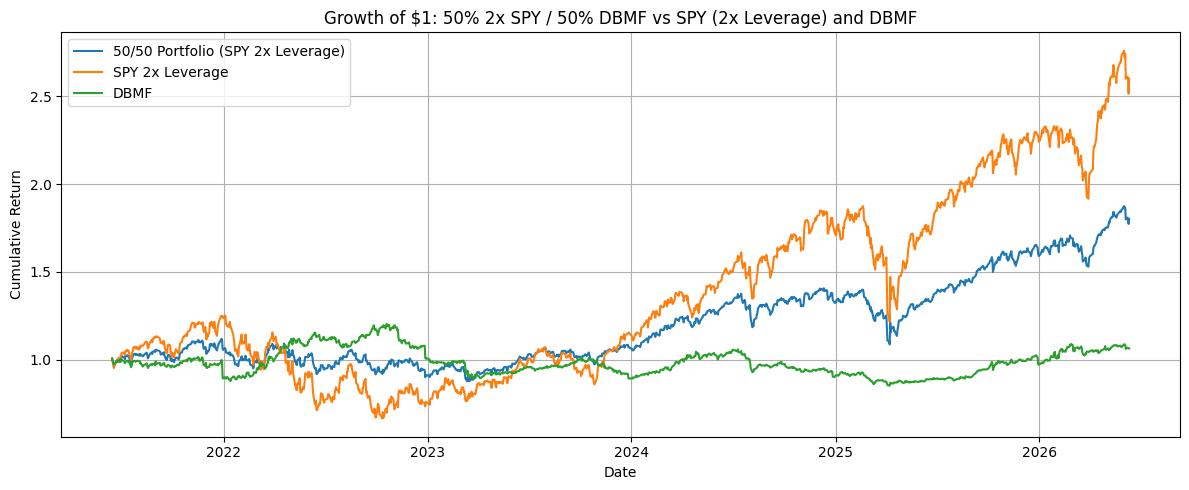

Sharpe Ratio (daily, annualized) for 50% 2x SPY / 50% DBMF Portfolio: 0.72
CAGR for 50% 2x SPY / 50% DBMF Portfolio: 12.52%
Max Drawdown for 50% 2x SPY / 50% DBMF Portfolio: -22.78%


In [32]:
# Construct a portfolio: 2x leveraged 'returns' (SPY) and 1x 'returns_DBMF', both at 50% weight
returns_portfolio = 0.5 * (2 * returns) + 0.5 * returns_DBMF

# Compute cumulative returns for the portfolio
cum_returns_portfolio = (1 + returns_portfolio).cumprod()

plt.figure(figsize=(12,5))
plt.plot(cum_returns_portfolio.index, cum_returns_portfolio, label="50/50 Portfolio (SPY 2x Leverage)")
plt.plot((1 + (2 * returns)).cumprod().index, (1 + (2 * returns)).cumprod(), label="SPY 2x Leverage")
plt.plot((1 + returns_DBMF).cumprod().index, (1 + returns_DBMF).cumprod(), label="DBMF")
plt.title('Growth of $1: 50% 2x SPY / 50% DBMF vs SPY (2x Leverage) and DBMF')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and print Sharpe ratio and CAGR for the 50/50 portfolio
sharpe_portfolio = (returns_portfolio.mean() / returns_portfolio.std()) * np.sqrt(252)
years_portfolio = (cum_returns_portfolio.index[-1] - cum_returns_portfolio.index[0]).days / 365.25
cagr_portfolio = (cum_returns_portfolio.iloc[-1] ** (1 / years_portfolio)) - 1

# Calculate max drawdown for the 50/50 portfolio
rolling_max = cum_returns_portfolio.cummax()
drawdown = cum_returns_portfolio / rolling_max - 1
max_drawdown = drawdown.min()

print(f"Sharpe Ratio (daily, annualized) for 50% 2x SPY / 50% DBMF Portfolio: {sharpe_portfolio:.2f}")
print(f"CAGR for 50% 2x SPY / 50% DBMF Portfolio: {cagr_portfolio:.2%}")
print(f"Max Drawdown for 50% 2x SPY / 50% DBMF Portfolio: {max_drawdown:.2%}")

---

#### 💭 Closing Thoughts and Future Topics

 **📑 TL;DW Executive Summary**

  - This lesson explored how overlaying a long volatility component onto a portfolio can actively combat volatility drag and make portfolios more resilient during market shocks and drawdowns.
  - We demonstrated that, compared to traditional "timing" approaches, a capital-efficient long vol overlay can not only smooth the ride through turbulent markets but actually enhance overall risk-adjusted returns—even when the market itself goes sideways or whipsaws.
  - Through code and an animated Plotly visualization, we quantified the impact: showing how the growth of $1, max drawdown, and performance ratios (Sharpe, Sortino, etc.) all improve with an intelligently constructed vol overlay as compared to simple market exposure.
  - Ultimately, you saw how quants use these techniques to go beyond trying (and failing) to "time the market," instead engineering portfolios that systematically benefit from volatility, turning a supposed drag into an edge.

 
**Future Topics**

Technical Videos and Other Discussions

 - Fama-French / Carhart and Factor Modeling in General
 - Hawkes Processes
 - Merton Jump Diffusion Model (and Characteristic Function Pricing, Carr-Madan 1999)
 - Market-Making Models and Simulation (Stoikov-Avellaneda)
 - My First Year as a Quant
 - Why Hedge Funds are Actually Secretive
 - Non-Markovian Models (fractional Brownian motion, Volterra Process)
 - Top 3 Uses of Linear Algebra for Quant Finance
 - Girsanov's Change of Measure
 - Rough Path Theory, Applications of Path Signatures
 - Sig-Vol Model, Calibration, and Pricing
 - Trading with Alternative Data Sources
 - Pairs Trading and Statistical Arbitrage
 - Data Cleaning & Outlier Handling in Financial Time Series
 - Practical Issues in Multi-Asset Portfolio Backtesting
 - Risk Premia Harvesting: Equity, FX, Rates

[Ideas for Interactive Brokers Apps and Tutorials](https://www.interactivebrokers.com/mkt/?src=quantguildY&url=%2Fen%2Fwhyib%2Foverview.php)

- How Interactive Broker's API Works (EWrapper/EClient)
- How to Backtest a Trading Strategy with Interactive Brokers
- Algorithmic Volatility Trading System

---

####  $\text{Copyright © 2026 Quant Guild} \quad \quad \quad \quad \text{Author: Roman Paolucci}$